# Redes Convolucionales con PyTorch

En este actividad se implementarán 3 modelos que usen una red neuronal convolucional usando PyTorch para el conjunto de datos CIFAR-10. Se evaluarán los tres modelos y se elegirá el mejor de los tres.

Nota: Se usó apoyo de la inteligencia artificial para implementar buenas prácticas al cargar los datos y desplegar algunas salidas.

In [37]:
# Imports

import random
import torch.nn as nn
import pandas as pd
import torch
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
import torchvision
import torchvision.transforms as transforms
import numpy as np
from PIL import Image

In [38]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

In [39]:
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

data_path = "./data/" if IN_COLAB else "./data/cifar_10/"

## Cargar conjunto de datos

In [40]:
# Se definen transformaciones para convertir las imagenes a tensores y paa aplicar normalización para mejorar el entrenamiento
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),  # mean
                         (0.5, 0.5, 0.5))  # std
])

In [41]:
# Cargar el dataset (entrenamiento y prueba)
train_dataset = torchvision.datasets.CIFAR10(
    root=data_path,
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root=data_path,
    train=False,
    download=True,
    transform=transform
)

In [42]:
# Implementar DataLoader para los batches
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [43]:
# Verificar clases de salida para clasificación
classes = train_dataset.classes
print(classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [44]:
# Verificar dimensiones de los datos (entradas y salidas)

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([64, 3, 32, 32])
torch.Size([64])


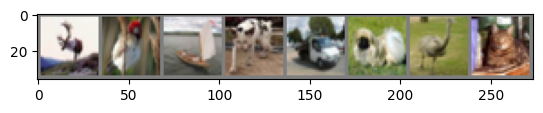

['deer', 'bird', 'ship', 'cat', 'truck', 'dog', 'bird', 'cat']


In [45]:
# Visualizar imágenes aleatorias de ejemplo del dataset
def imshow(img):
    img = img / 2 + 0.5  # desnormalizar
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

num_images = 8
indices = random.sample(range(len(train_dataset)), num_images)

images = [train_dataset[i][0] for i in indices]
labels = [train_dataset[i][1] for i in indices]

images_tensor = torch.stack(images)

imshow(torchvision.utils.make_grid(images_tensor))
print([classes[label] for label in labels])

## Definir 3 Redes Neuronales Convolucionales

In [46]:
# Función de pérdida
loss_fn = nn.CrossEntropyLoss()

# Modelo 1
model_1 = nn.Sequential(
    nn.Conv2d(3, 16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    nn.Conv2d(16, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    nn.Flatten(),
    nn.Linear(32 * 8 * 8, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

# Modelo 2
model_2 = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    nn.Conv2d(64, 128, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    nn.Flatten(),
    nn.Linear(128 * 4 * 4, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 10)
)

# Modelo 3
model_3 = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.Conv2d(32, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.Conv2d(64, 64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    nn.Conv2d(64, 128, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    nn.Flatten(),
    nn.Linear(128 * 4 * 4, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 10)
)

# Usar el dispositivo definido por Cuda
model_1.to(device)
model_2.to(device)
model_3.to(device)

# Optimizadores
optimizer_1 = torch.optim.Adam(model_1.parameters(), lr=0.001)
optimizer_2 = torch.optim.Adam(model_2.parameters(), lr=0.001)
optimizer_3 = torch.optim.Adam(model_3.parameters(), lr=0.001)

# Número de épocas
num_epochs = 7

## Entrenamiento de los 3 modelos

In [47]:
# Funcion para evaluar el modelo
def evaluate(model, dataloader, loss_fn):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            # Mover datos a dispositivo Cuda
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = loss_fn(outputs, y_batch)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total

    return avg_loss, accuracy


# Funcion para entrenar un batch
def train_batch(model, X_batch, y_batch, optimizer, loss_fn):
    # Mover datos a dispositivo Cuda
    X_batch = X_batch.to(device)
    y_batch = y_batch.to(device)

    # Forward pass
    predictions = model(X_batch)
    loss = loss_fn(predictions, y_batch)

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()


# Funcion de entrenamiento completo para un modelo
def train_function(model, train_loader, test_loader, optimizer, loss_fn, num_epochs):

    train_losses = []
    test_losses = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0

        for X_batch, y_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            loss = train_batch(model, X_batch, y_batch, optimizer, loss_fn)

            # calcular loss del batch para promedio
            running_loss += loss

        # promedio de pérdida en entrenamiento
        epoch_train_loss = running_loss / len(train_loader)
        train_losses.append(epoch_train_loss)

        # evaluación en test
        test_loss, test_acc = evaluate(model, test_loader, loss_fn)
        test_losses.append(test_loss)

        print(f"Epoch {epoch+1}:")
        print(f"  Train Loss: {epoch_train_loss:.4f}")
        print(f"  Test  Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

    return train_losses, test_losses

In [48]:
train_losses_1, test_losses_1 = train_function(
    model_1, train_loader, test_loader, optimizer_1, loss_fn, num_epochs
)

Epoch 1/7: 100%|██████████| 782/782 [00:14<00:00, 55.14it/s]


Epoch 1:
  Train Loss: 1.4431
  Test  Loss: 1.2094, Acc: 0.5748


Epoch 2/7: 100%|██████████| 782/782 [00:14<00:00, 55.32it/s]


Epoch 2:
  Train Loss: 1.0960
  Test  Loss: 1.0793, Acc: 0.6151


Epoch 3/7: 100%|██████████| 782/782 [00:14<00:00, 54.69it/s]


...

Epoch 5:
  Train Loss: 0.7720
  Test  Loss: 0.8862, Acc: 0.6933


Epoch 6/7: 100%|██████████| 782/782 [00:16<00:00, 47.38it/s]


Epoch 6:
  Train Loss: 0.7073
  Test  Loss: 0.8820, Acc: 0.6974


Epoch 7/7: 100%|██████████| 782/782 [00:15<00:00, 51.24it/s]


Epoch 7:
  Train Loss: 0.6444
  Test  Loss: 0.8932, Acc: 0.6943


In [49]:
train_losses_2, test_losses_2 = train_function(
    model_2, train_loader, test_loader, optimizer_2, loss_fn, num_epochs
)

Epoch 1/7: 100%|██████████| 782/782 [00:17<00:00, 43.50it/s]


Epoch 1:
  Train Loss: 1.4230
  Test  Loss: 1.0918, Acc: 0.6050


Epoch 2/7: 100%|██████████| 782/782 [00:17<00:00, 45.21it/s]


Epoch 2:
  Train Loss: 1.0033
  Test  Loss: 0.8799, Acc: 0.6883


Epoch 3/7: 100%|██████████| 782/782 [00:16<00:00, 47.48it/s]


...

Epoch 5:
  Train Loss: 0.6194
  Test  Loss: 0.7407, Acc: 0.7469


Epoch 6/7: 100%|██████████| 782/782 [00:16<00:00, 47.09it/s]


Epoch 6:
  Train Loss: 0.5485
  Test  Loss: 0.7075, Acc: 0.7611


Epoch 7/7: 100%|██████████| 782/782 [00:15<00:00, 50.51it/s]


Epoch 7:
  Train Loss: 0.4802
  Test  Loss: 0.6871, Acc: 0.7643


In [50]:
train_losses_3, test_losses_3 = train_function(
    model_3, train_loader, test_loader, optimizer_3, loss_fn, num_epochs
)

Epoch 1/7: 100%|██████████| 782/782 [00:22<00:00, 35.34it/s]


Epoch 1:
  Train Loss: 1.5580
  Test  Loss: 1.1883, Acc: 0.5721


Epoch 2/7: 100%|██████████| 782/782 [00:21<00:00, 36.55it/s]


Epoch 2:
  Train Loss: 1.0720
  Test  Loss: 0.9663, Acc: 0.6630


Epoch 3/7: 100%|██████████| 782/782 [00:21<00:00, 37.11it/s]


...

Epoch 5:
  Train Loss: 0.6559
  Test  Loss: 0.6863, Acc: 0.7617


Epoch 6/7: 100%|██████████| 782/782 [00:21<00:00, 36.27it/s]


Epoch 6:
  Train Loss: 0.5807
  Test  Loss: 0.6824, Acc: 0.7655


Epoch 7/7: 100%|██████████| 782/782 [00:20<00:00, 38.64it/s]


Epoch 7:
  Train Loss: 0.5133
  Test  Loss: 0.6769, Acc: 0.7715


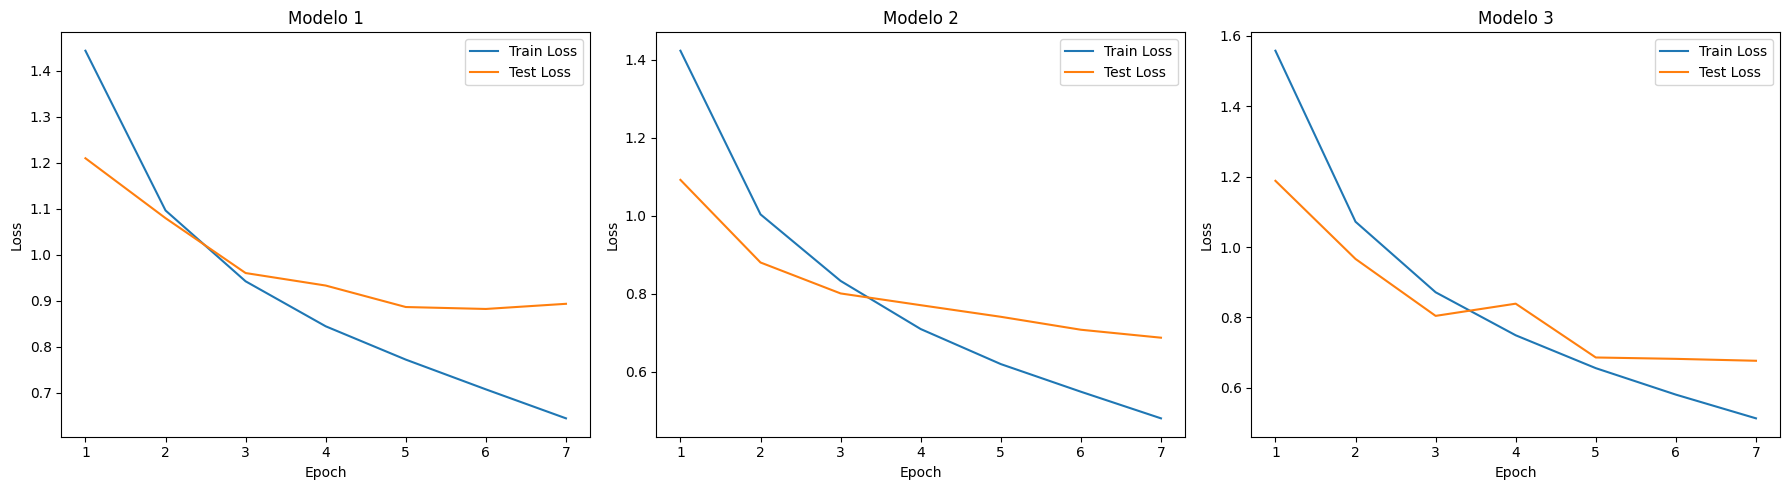

In [51]:
# Mostrar curvas de aprendizaje de los 3 modelos

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(18,5))

# Modelo 1
plt.subplot(1, 3, 1)
plt.plot(epochs, train_losses_1, label="Train Loss")
plt.plot(epochs, test_losses_1, label="Test Loss")
plt.title("Modelo 1")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Modelo 2
plt.subplot(1, 3, 2)
plt.plot(epochs, train_losses_2, label="Train Loss")
plt.plot(epochs, test_losses_2, label="Test Loss")
plt.title("Modelo 2")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Modelo 3
plt.subplot(1, 3, 3)
plt.plot(epochs, train_losses_3, label="Train Loss")
plt.plot(epochs, test_losses_3, label="Test Loss")
plt.title("Modelo 3")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## Evaluación del mejor modelo

In [52]:
# Mostrar evaluacion de los tres modelos

results = []

for i, model in enumerate([model_1, model_2, model_3], start=1):
    train_loss, train_acc = evaluate(model, train_loader, loss_fn)
    test_loss, test_acc = evaluate(model, test_loader, loss_fn)

    results.append({
        "Modelo": f"Modelo {i}",
        "Train Loss": train_loss,
        "Test Loss": test_loss,
        "Train Acc": train_acc,
        "Test Acc": test_acc
    })

df_results = pd.DataFrame(results)
df_results

,Modelo,Train Loss,Test Loss,Train Acc,Test Acc
0,Modelo 1,0.578146,0.893200,0.80064,0.6943
1,Modelo 2,0.337416,0.687059,0.89054,0.7643
2,Modelo 3,0.370991,0.676920,0.87386,0.7715


Se eligió el modelo 3 ya que fue el que presentó mejores resultados para los datos de prueba. Este modelo tuvo la pérdida más baja y el accuracy más elevado.

In [56]:
# Seleccionar y evaluar el mejor modelo

best_model = model_3

_, test_acc = evaluate(best_model, test_loader, loss_fn)

print(f"Accuracy en test del mejor modelo: {test_acc:.4f}")

Accuracy en test del mejor modelo: 0.7715


## Puntos extra: Función para clasificar imagen arbitraria

In [57]:
# Función para usar el modelo para una imagen arbitraria
def predict_image(image_path, model=best_model, classes=classes):
    model.eval()

    # Transformación de la imagen
    transform = transforms.Compose([
        transforms.Resize((32, 32)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5),
                             (0.5, 0.5, 0.5))
    ])

    # Cargar imagen original
    original_image = Image.open(image_path).convert("RGB")

    # Aplicar transformación
    processed_image = transform(original_image)

    # Agregar dimensión batch (formato esperado por el modelo CNN, predice batches)
    input_image = processed_image.unsqueeze(0).to(device)

    # Predicción
    with torch.no_grad():
        outputs = model(input_image)
        _, predicted = torch.max(outputs, 1)
        predicted_class = classes[predicted.item()]

    # Mostrar imágenes
    plt.figure(figsize=(8,4))

    # Mostrar imagen original
    plt.subplot(1,2,1)
    plt.imshow(original_image)
    plt.title("Original")
    plt.axis('off')

    # Mostrar imagen escalada (desnormalizada)
    img = processed_image * 0.5 + 0.5
    npimg = img.numpy().transpose((1,2,0))

    plt.subplot(1,2,2)
    plt.imshow(npimg)
    plt.title("Procesada (32x32)")
    plt.axis('off')

    plt.show()

    print(f"Clase predicha: {predicted_class}")

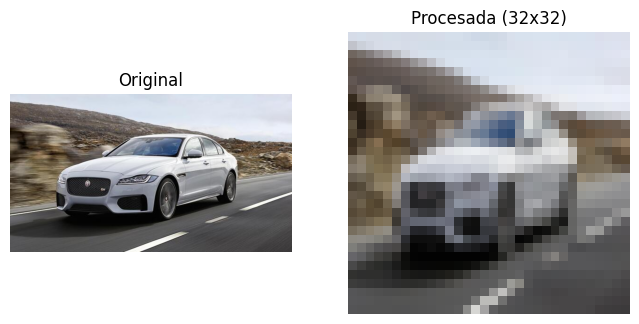

Clase predicha: automobile


In [59]:
# Probar la función con imagen arbitraria
img_path = data_path + "imagen_prueba.jpg"

predict_image(img_path)

## Reflexiones personales

Al realizar esta actividad pude poner en práctica la implementación de una red neuronal convolucional. A partir de esta actividad pude aprender que para problemas no tan básicos como lo es una clasificación multiclase con 10 categorías de salida teniendo como entrada una imagen, los modelos de redes neuronales convolucionales se benefician de una arquitectura más compleja, ya que viendo los resultados obtenidos de esta actividad, el modelo más sencillo tuvo notablemente un desempeño peor con respecto a los otros dos modelos que tenían arquitecturas con más capas. Además, inicialmente se establecieron 10 épocas de entrenamiento para los modelos, lo cual resultó en algo de overfitting. Esto me hizo darme cuenta de que incluso en problemas complejos, a veces pocas épocas puede ser suficiente y lo ideal para lograr un mejor modelo. En este caso, se observó que alrededor de 7 épocas es el punto ideal para lograr el mejor modelo dados los datos y modelos definidos para este problema. Más de eso resultó en que la pérdida en prueba comenzaba a aumentar. Además, esta actividad me permitió conocer un poco más sobre cómo manejar imágenes usando PIL de Python. Esta resulta ser una herramienta que hace muy sencilla la modificación y manejo de imágenes en Python, aunque es importante tener encuenta que se debe de convertir a tensores los datos para poder usarlos con PyTorch. En general, realizar esta actividad resultó interesante ya que me hizo darme cuenta de la capacidad que tienen las CNN para poder procesar imágenes, pues los modelos resultantes tuvieron resultados bastante aceptables, al menos los dos más complejos.